
# Principal Component Analysis of Breast Cancer Gene Expression

## Overview
This notebook investigates breast cancer gene-expression profiles using Principal Component Analysis (PCA).  
The goal is to explore whether dimensionality reduction can reveal natural grouping patterns between ER-positive and ER-negative samples.

---

## Dataset Components
The analysis uses three separate files:

| File | Purpose |
|------|---------|
| Class Labels | Stores ER classification for each patient sample |
| Expression Matrix | Contains normalized gene-expression measurements |
| Gene Metadata | Provides information about gene identifiers |

The datasets are combined and cleaned before visualization and PCA computation.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gzip
from io import StringIO

# Load class labels (1 = ER+, 0 = ER-)
class_labels = pd.read_csv('data/class.tsv', sep='\t', header=None)
labels = class_labels[0].values

# Load gene mapping data
with gzip.open('data/columns.tsv.gz', 'rt') as f:
    lines = [line for line in f if not line.startswith('#')]
filtered_content = StringIO(''.join(lines))
gene_mapping = pd.read_csv(filtered_content, sep='\t')

# Load gene expression data
with gzip.open('data/filtered.tsv.gz', 'rt') as f:
    expression_data = pd.read_csv(f, sep='\t')
expression_data.columns = expression_data.columns.astype(str).str.strip()

# Retrieve gene IDs for XBP1 and GATA3
xbp1_id = 4404
gata3_id = gene_mapping[gene_mapping['GeneSymbol'] == 'GATA3']['ID'].values[0]

print(gata3_id)
print('4404' in expression_data.columns)

# Extract expression values
xbp1_expression = expression_data[str(xbp1_id)].values
gata3_expression = expression_data[str(gata3_id)].values

# Assign colors for visualization based on class labels
colors = ['black' if label == 0 else 'red' for label in labels]


4359
True



# PCA Workflow and Mathematical Intuition

Rather than directly plotting high-dimensional gene-expression data, PCA transforms the data into a smaller set of informative directions called **principal components**.

The notebook follows these stages:

### Step 1 — Standardization
The dataset is mean-centered so that every feature contributes relative variation instead of raw magnitude.

### Step 2 — Covariance Analysis
A covariance matrix is generated to measure how genes vary together.

### Step 3 — Eigenvector Extraction
Eigenvectors determine the directions of maximum variation in the data.

### Step 4 — Dimensionality Reduction
Samples are projected onto lower-dimensional axes while preserving the largest possible variance.

This process allows easier visualization of biological trends hidden inside large genomic datasets.


In [3]:
def perform_pca(X, labels=None, k=None):
    """
    Perform PCA with consistent orientation of principal components for 2D visualization.

    Parameters:
    X : numpy array (n_samples x n_features)
    labels : numpy array, optional (n_samples,)
        Binary class labels for orientation (1 = ER+, 0 = ER-)
    k : int, optional
        Number of principal components to return

    Returns:
    eigenvectors : numpy array
        Oriented eigenvectors
    eigenvalues : numpy array
        Corresponding eigenvalues
    x_centered : numpy array
        Mean-centered input data
    """
    x_centered = X - np.mean(X, axis=0)
    cov_matrix = np.cov(x_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # Orient PC1 based on correlation with labels
    if labels is not None:
        pc1 = eigenvectors[:, 0]
        proj_pc1 = np.dot(x_centered, pc1)
        if np.mean(proj_pc1[labels == 1]) < np.mean(proj_pc1[labels == 0]):
            eigenvectors[:, 0] *= -1  # Flip PC1

        # For 2D: Flip PC2 to maintain right-handed coordinate system
        if eigenvectors.shape[1] >= 2:
            pc1 = eigenvectors[:, 0]
            pc2 = eigenvectors[:, 1]
            cross = np.cross(pc1, pc2)
            if cross < 0:
                eigenvectors[:, 1] *= -1  # Flip PC2 to ensure right-handed system

    if k is not None:
        eigenvectors = eigenvectors[:, :k]
        eigenvalues = eigenvalues[:k]

    return eigenvectors, eigenvalues, x_centered



# Figure A — Gene Expression Distribution

The first visualization compares expression levels of two biologically relevant genes across patient samples.

### What this figure demonstrates
- Individual points correspond to patient samples.
- Distinct marker colors indicate ER classification.
- Cluster separation may indicate biologically meaningful differences between tumor groups.

This serves as an intuitive introduction before applying PCA-based transformations.


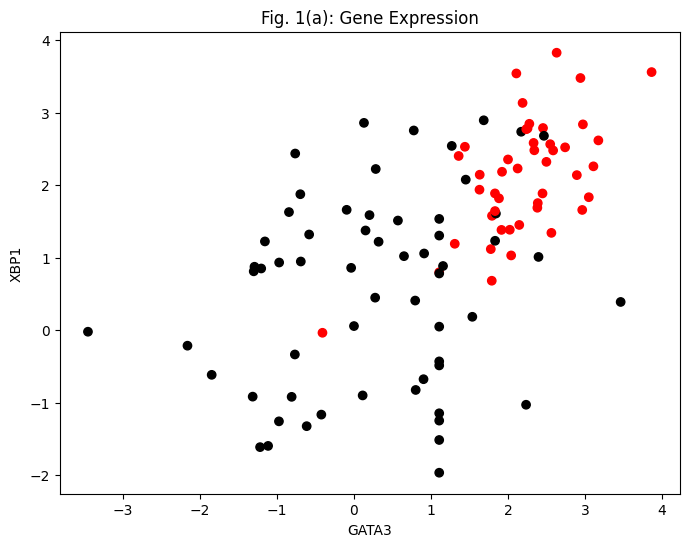

In [4]:
plt.figure(figsize=(12, 7))
plt.scatter(gata3_expression, xbp1_expression, c=['#008B8B' if l == 1 else '#C71585' for l in labels])
plt.xlabel('GATA3')
plt.ylabel('XBP1')
plt.title('Figure A: Comparative Gene Expression Landscape')
plt.savefig('figure_1a.png')
plt.grid(linestyle='--', alpha=0.4)
plt.show()



# Figure B — Principal Component Orientation

This figure overlays the principal component directions on the original feature space.

### Interpretation
- **PC1** captures the strongest variance direction.
- **PC2** captures secondary variance while remaining orthogonal to PC1.
- Arrow vectors indicate how PCA rotates the coordinate system.

The transformation helps summarize complex gene relationships using only a few dimensions.


C:\Users\yashj\AppData\Local\Temp\ipykernel_25836\370014892.py:39: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  cross = np.cross(pc1, pc2)


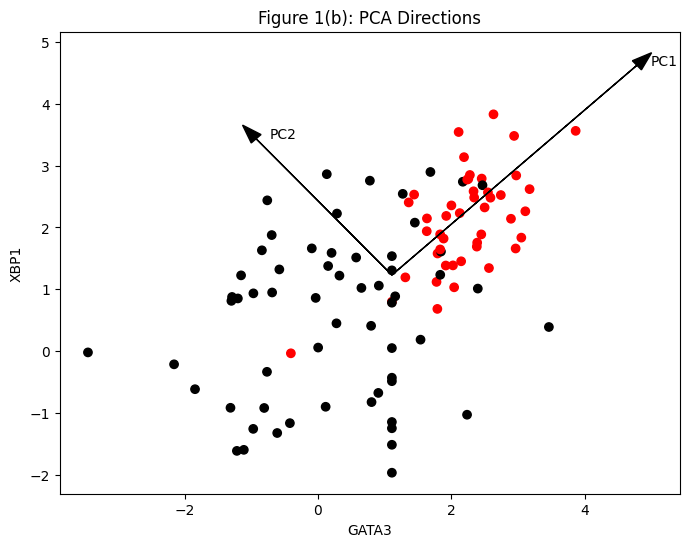

In [5]:
x = np.column_stack((gata3_expression, xbp1_expression))
eigenvectors, eigenvalues, x_centered = perform_pca(x, labels=labels)

pc1 = eigenvectors[:, 0]
pc2 = eigenvectors[:, 1]
projection_pc1 = np.dot(x_centered, pc1)
projection_pc2 = np.dot(x_centered, pc2)

plt.figure(figsize=(12, 7))
plt.scatter(gata3_expression, xbp1_expression, c=['#008B8B' if l == 1 else '#C71585' for l in labels])

mean_gata3 = np.mean(gata3_expression)
mean_xbp1 = np.mean(xbp1_expression)

plt.arrow(mean_gata3, mean_xbp1, pc1[0]*5, pc1[1]*5,
          head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(mean_gata3, mean_xbp1, pc2[0]*3, pc2[1]*3,
          head_width=0.2, head_length=0.3, fc='black', ec='black')

plt.text(mean_gata3 + pc1[0]*5 + 0.2, mean_xbp1 + pc1[1]*5, 'PC1')
plt.text(mean_gata3 + pc2[0]*3 + 0.2, mean_xbp1 + pc2[1]*3, 'PC2')

plt.xlabel('GATA3')
plt.ylabel('XBP1')
plt.title('Figure B: Principal Component Vector Visualization: PCA Directions')
plt.savefig('figure_1b.png')
plt.grid(linestyle='--', alpha=0.4)
plt.show()



# Figure C — Projection onto PC1

The final visualization studies how samples distribute along the first principal component.

### Key Insight
If ER+ and ER− samples occupy different regions along PC1, then PCA successfully captures biologically meaningful variance.

The histograms and projections provide a compact representation of separation between classes.


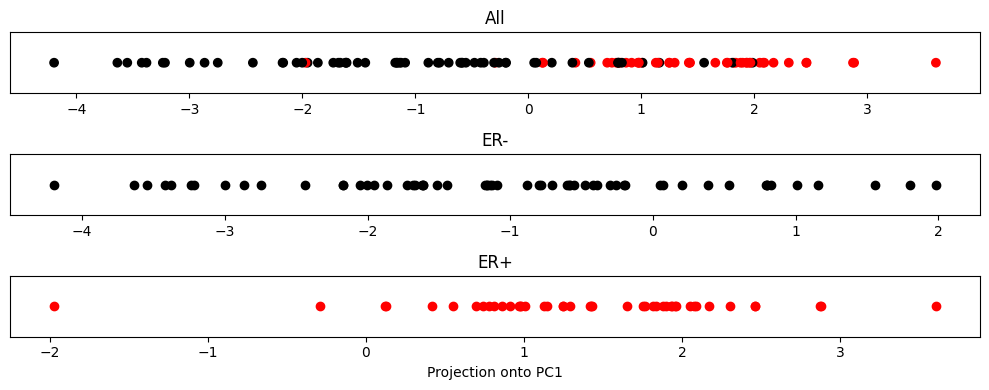

Variance explained by PC1: 0.7792
Variance explained by PC2: 0.2208


In [6]:
# Separate projections based on class labels
er_pos_pc1 = projection_pc1[labels == 1]
er_neg_pc1 = projection_pc1[labels == 0]

plt.figure(figsize=(13, 6))

# All samples
plt.subplot(3, 1, 1)
plt.scatter(projection_pc1, np.zeros_like(projection_pc1), c=['#008B8B' if l == 1 else '#C71585' for l in labels])
plt.yticks([])
plt.title('All')

# ER- samples
plt.subplot(3, 1, 2)
plt.scatter(er_neg_pc1, np.zeros_like(er_neg_pc1), c='black')
plt.yticks([])
plt.title('ER-')

# ER+ samples
plt.subplot(3, 1, 3)
plt.scatter(er_pos_pc1, np.zeros_like(er_pos_pc1), c='red')
plt.yticks([])
plt.title('ER+')
plt.xlabel('Projection onto PC1')

plt.tight_layout()
plt.savefig('figure_1c.png')
plt.grid(linestyle='--', alpha=0.4)
plt.show()

# Variance explained by PC1 and PC2
print(f"Variance explained by PC1: {eigenvalues[0]/sum(eigenvalues):.4f}")
print(f"Variance explained by PC2: {eigenvalues[1]/sum(eigenvalues):.4f}")
